In [24]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import sys
from pathlib import Path

root = Path.cwd().resolve()

if not (root / "data").exists():
    root = root.parent

if not (root / "src").exists():
    root = root.parent

if not (root / "data").exists():
    root = root.parent

if not (root / "outputs").exists():
    root = root.parent

if str(root) not in sys.path:
    sys.path.append(str(root))

charts_dir = root / "outputs" / "charts"
charts_dir.mkdir(parents=True, exist_ok=True)

sns.set_theme(style="whitegrid")

# Set this before running the ultimate analysis cells, e.g. "Argentina".
# Leave blank to include every team.
LEAVE_ONE_OUT_TEAM = ""

Saved chart: C:\Users\perei\OneDrive\Desktop\wc26\outputs\charts\ultimate_do_bigger_teams_get_the_whistle.png
Saved match summary: C:\Users\perei\OneDrive\Desktop\wc26\outputs\charts\ultimate_match_whistle_summary.csv


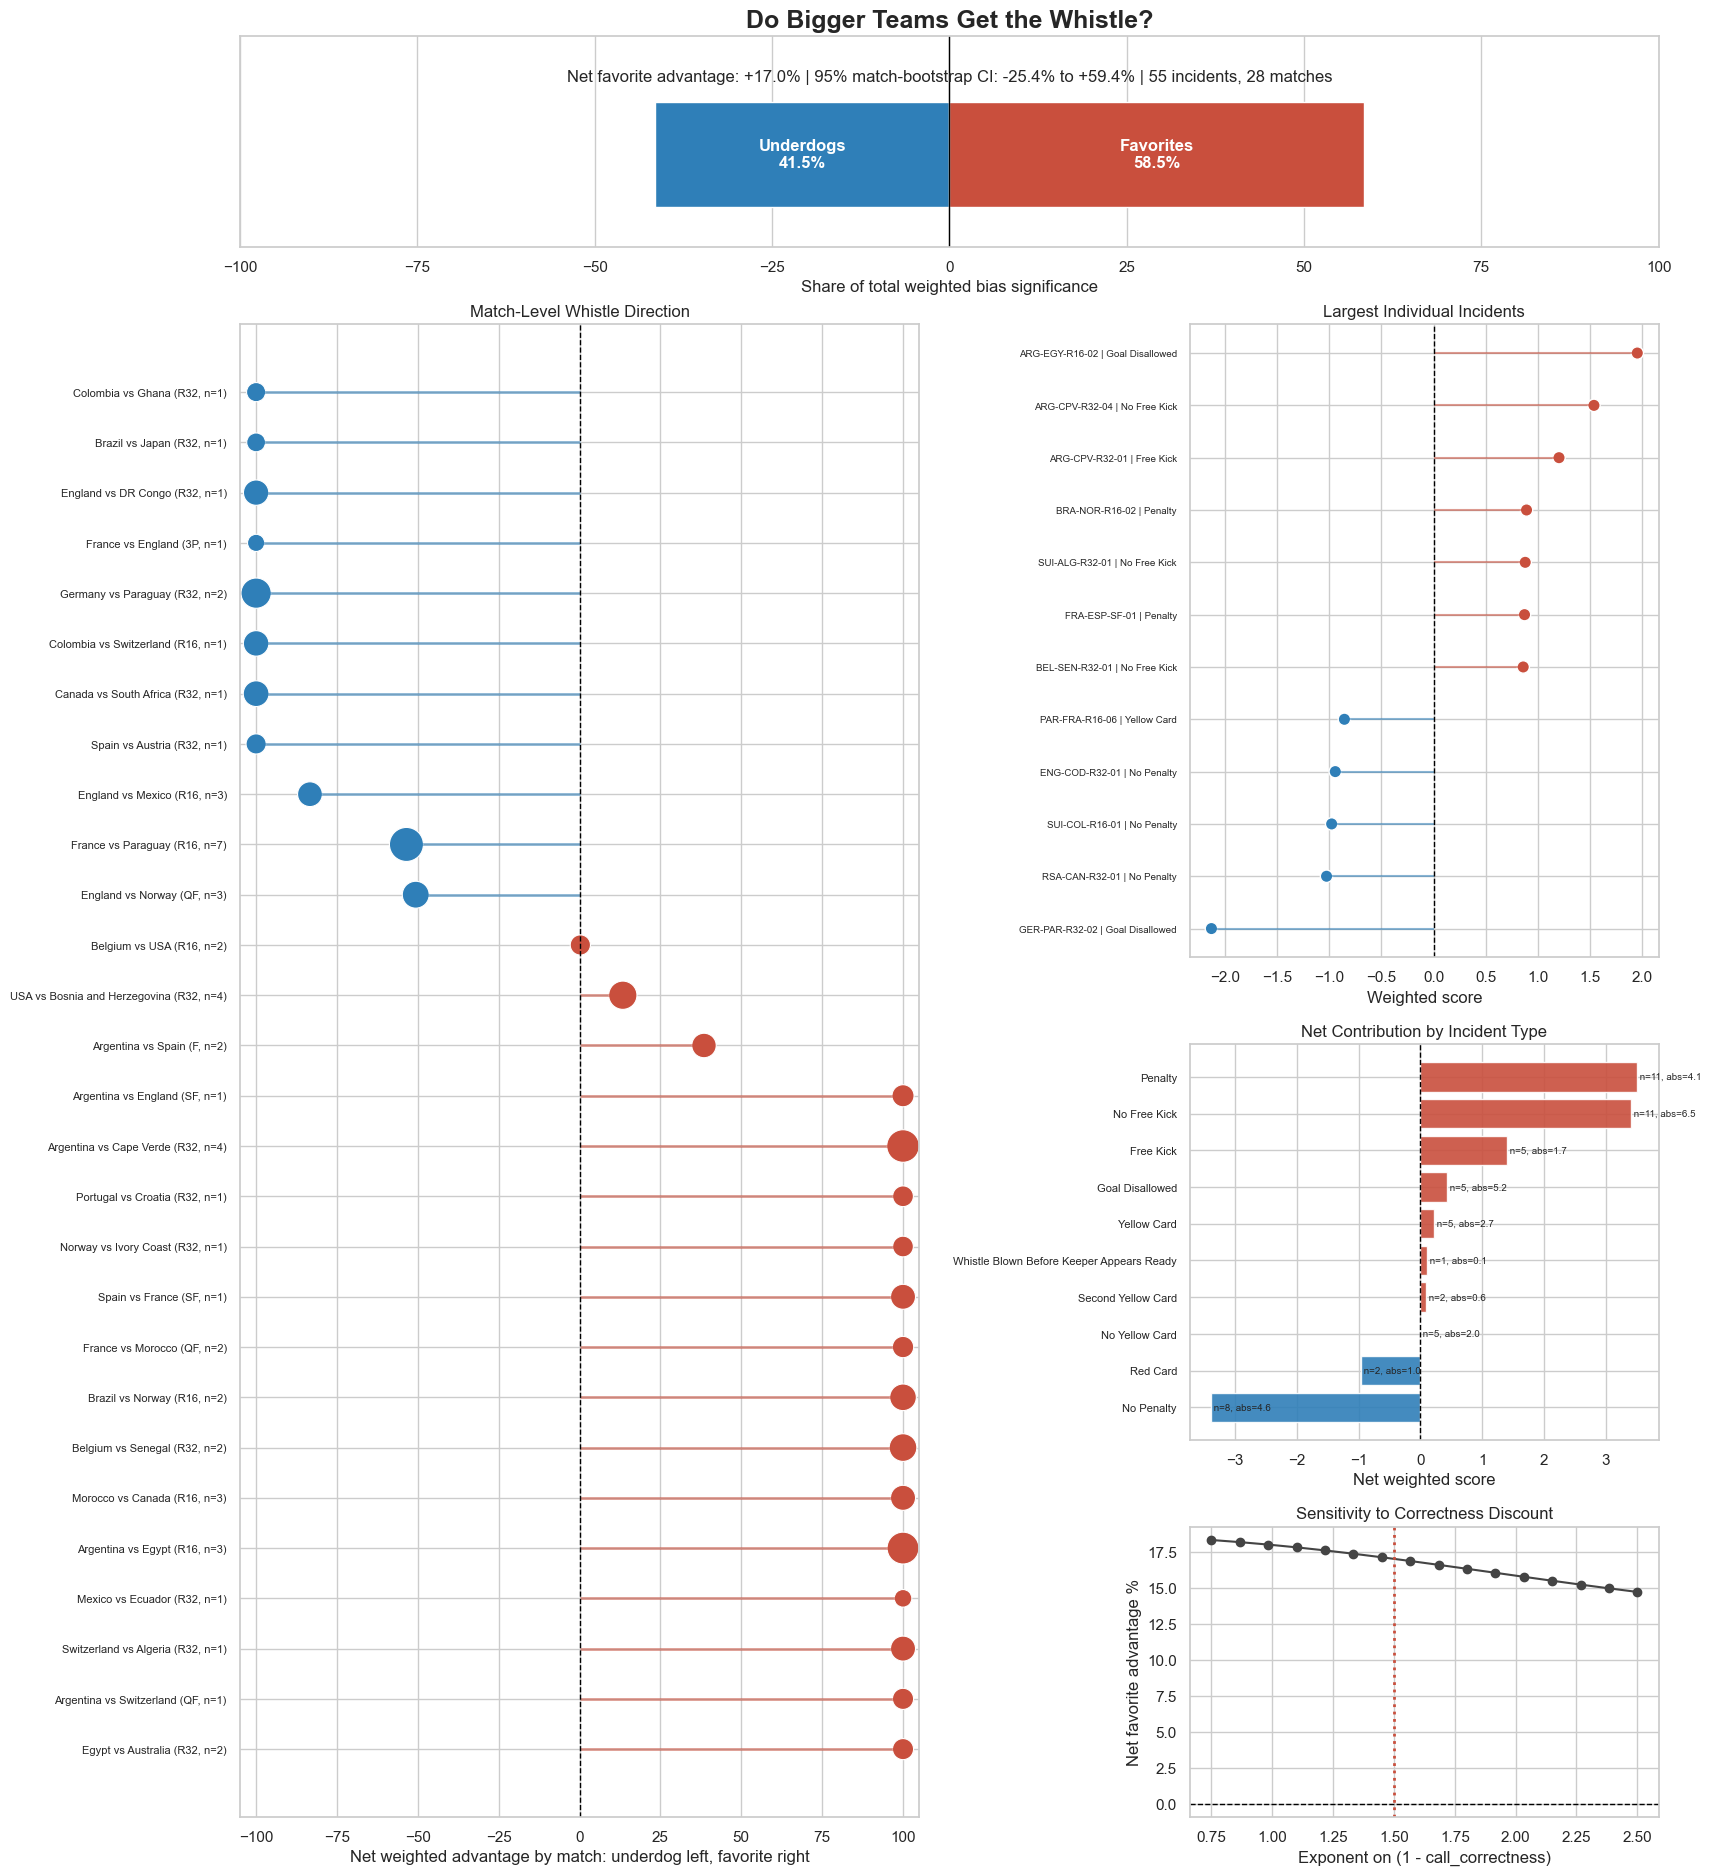

In [25]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.gridspec import GridSpec

CORRECTNESS_EXPONENT = 1.5
STANDARD_FIT_BOOST = 0.5
N_BOOTSTRAPS = 20_000
SEED = 42

FAV_COLOR = "#c94f3d"
DOG_COLOR = "#2f7fb8"
NEUTRAL = "#767676"
LEAVE_ONE_OUT_TEAM = globals().get("LEAVE_ONE_OUT_TEAM", "")

def find_root():
    here = Path.cwd().resolve()
    for p in [here, *here.parents]:
        if (p / "data/manual/decision.csv").exists():
            return p
    raise FileNotFoundError("Run from inside the wc26 repo.")

def norm_text(s):
    return s.astype("string").str.strip().str.replace(r"\s+", " ", regex=True).str.casefold()

def norm_bool(s):
    return s.astype("string").str.strip().str.casefold().map({"true": True, "false": False})

def title_team(x):
    name = str(x).title().replace("Usa", "USA").replace("Dr Congo", "DR Congo")
    return name.replace(" And ", " and ")

def normalize_team_value(team):
    return " ".join(str(team).strip().split()).casefold()

def leave_one_out_filter(data, team, columns=("favored_team", "underdog_team", "team_benefited", "team_hurt")):
    if team is None or str(team).strip() == "":
        return data.copy(), pd.DataFrame(columns=data.columns), "", ""

    team_key = normalize_team_value(team)
    team_columns = [col for col in columns if col in data.columns]
    involved = data[team_columns].eq(team_key).fillna(False).any(axis=1)

    if not involved.any():
        available = sorted(pd.unique(data[team_columns].stack().dropna()))
        options = ", ".join(title_team(x) for x in available)
        raise ValueError(f"No incidents found for '{team}'. Try one of: {options}")

    remaining = data.loc[~involved].copy()
    dropped = data.loc[involved].copy()
    label = title_team(team_key)
    slug = team_key.replace(" ", "_")

    if remaining.empty:
        raise ValueError(f"Leave-one-out removed every incident for {label}.")

    print(
        f"Leave-one-out: removed {len(dropped)} incidents across "
        f"{dropped['match'].nunique()} matches involving {label}."
    )
    return remaining, dropped, label, slug

def weighted_score(df, exponent=CORRECTNESS_EXPONENT, boost=STANDARD_FIT_BOOST):
    wrongness = (1 - df["call_correctness"]).clip(0, 1) ** exponent
    consistency_boost = 1 + boost * df["standard_fit"].abs()
    return df["score"] * wrongness * df["confidence"] * consistency_boost

def bootstrap_match_ci(matches):
    rng = np.random.default_rng(SEED)
    net = matches["net_whistle"].to_numpy(float)
    sig = matches["total_significance"].to_numpy(float)
    idx = rng.integers(0, len(matches), size=(N_BOOTSTRAPS, len(matches)))
    boot_net = net[idx].sum(axis=1)
    boot_sig = sig[idx].sum(axis=1)
    boot_pct = np.divide(100 * boot_net, boot_sig, out=np.full(N_BOOTSTRAPS, np.nan), where=boot_sig > 0)
    return np.nanpercentile(boot_pct, [2.5, 97.5])

root = find_root()
charts_dir = root / "outputs/charts"
charts_dir.mkdir(parents=True, exist_ok=True)

decisions = pd.read_csv(root / "data/manual/decision.csv", comment="#")
context = pd.read_csv(root / "data/manual/match_context.csv").rename(columns={"match_name": "match"})

for col in ["match", "favored_team", "underdog_team", "team_benefited", "team_hurt"]:
    decisions[col] = norm_text(decisions[col])
for col in ["match", "favored_team", "underdog_team", "winner"]:
    context[col] = norm_text(context[col])

decisions["stage"] = decisions["stage"].astype("string").str.strip().str.upper()
context["stage"] = context["stage"].astype("string").str.strip().str.upper()
decisions["incident_type"] = decisions["incident_type"].astype("string").str.strip()
decisions["decision"] = decisions["decision"].astype("string").str.strip()

for col in ["minute", "score", "call_correctness", "confidence", "standard_fit"]:
    decisions[col] = pd.to_numeric(decisions[col], errors="raise")
context["spread"] = pd.to_numeric(context["spread"], errors="coerce")

decisions["VAR_involved"] = norm_bool(decisions["VAR_involved"]).fillna(False).astype(bool)
decisions["favored_team_benefited"] = norm_bool(decisions["favored_team_benefited"])

bad_ranges = decisions[
    ~decisions["score"].between(-4, 4)
    | ~decisions["call_correctness"].between(0, 1)
    | ~decisions["confidence"].between(0, 1)
    | ~decisions["standard_fit"].between(-1, 1)
]
if not bad_ranges.empty:
    raise ValueError(bad_ranges[["incident_id", "score", "call_correctness", "confidence", "standard_fit"]])

df = decisions.merge(
    context,
    on="match",
    how="left",
    suffixes=("", "_context"),
    validate="many_to_one",
)

df, leave_one_out_dropped, leave_one_out_label, leave_one_out_slug = leave_one_out_filter(
    df,
    LEAVE_ONE_OUT_TEAM,
)

df["whistle_weight"] = weighted_score(df)
df["whistle_significance"] = df["whistle_weight"].abs()
df["whistle_side"] = np.select(
    [df["whistle_weight"] > 0, df["whistle_weight"] < 0],
    ["favorite", "underdog"],
    default="neutral",
)

match_table = (
    df.groupby("match", as_index=False)
    .agg(
        stage=("stage", "first"),
        favored_team=("favored_team", "first"),
        underdog_team=("underdog_team", "first"),
        winner=("winner", "first"),
        spread=("spread", "first"),
        incidents=("incident_id", "count"),
        var_count=("VAR_involved", "sum"),
        net_whistle=("whistle_weight", "sum"),
        total_significance=("whistle_significance", "sum"),
    )
)
match_table = match_table[match_table["total_significance"] > 0].copy()
if match_table.empty:
    raise ValueError("No non-zero evidence remains after the leave-one-out filter.")

match_table["favorite_advantage_pct"] = 100 * match_table["net_whistle"] / match_table["total_significance"]
match_table["label"] = match_table.apply(
    lambda r: f"{title_team(r['favored_team'])} vs {title_team(r['underdog_team'])} ({r['stage']}, n={r['incidents']})",
    axis=1,
)

total_net = df["whistle_weight"].sum()
total_sig = df["whistle_significance"].sum()
if total_sig <= 0:
    raise ValueError("No weighted bias significance remains after the leave-one-out filter.")

overall_pct = 100 * total_net / total_sig
fav_share = 100 * ((total_sig + total_net) / 2) / total_sig
dog_share = 100 * ((total_sig - total_net) / 2) / total_sig
ci_low, ci_high = bootstrap_match_ci(match_table)

types = (
    df.groupby("decision", as_index=False)
    .agg(net=("whistle_weight", "sum"), sig=("whistle_significance", "sum"), n=("incident_id", "count"))
    .sort_values("net")
)

top_inc = (
    df.nlargest(12, "whistle_significance")
    .sort_values("whistle_weight")
    .assign(label=lambda x: x["incident_id"] + " | " + x["decision"])
)

exponents = np.linspace(0.75, 2.5, 16)
sensitivity = [
    100 * weighted_score(df, exponent=e).sum() / weighted_score(df, exponent=e).abs().sum()
    for e in exponents
]

fig = plt.figure(figsize=(17, max(13, 0.38 * len(match_table) + 8)), constrained_layout=True)
gs = GridSpec(4, 2, figure=fig, width_ratios=[1.45, 1], height_ratios=[0.8, 2.4, 1.5, 1.1])

ax_answer = fig.add_subplot(gs[0, :])
ax_match = fig.add_subplot(gs[1:, 0])
ax_inc = fig.add_subplot(gs[1, 1])
ax_type = fig.add_subplot(gs[2, 1])
ax_sens = fig.add_subplot(gs[3, 1])

ax_answer.barh(0, -dog_share, color=DOG_COLOR)
ax_answer.barh(0, fav_share, color=FAV_COLOR)
ax_answer.axvline(0, color="black", lw=1)
ax_answer.set_xlim(-100, 100)
ax_answer.set_ylim(-0.7, 0.9)
ax_answer.set_yticks([])
title_suffix = f" (without {leave_one_out_label})" if leave_one_out_label else ""
ax_answer.set_title(f"Do Bigger Teams Get the Whistle?{title_suffix}", fontsize=18, weight="bold")
ax_answer.set_xlabel("Share of total weighted bias significance")
ax_answer.text(-dog_share / 2, 0, f"Underdogs\n{dog_share:.1f}%", color="white", ha="center", va="center", weight="bold")
ax_answer.text(fav_share / 2, 0, f"Favorites\n{fav_share:.1f}%", color="white", ha="center", va="center", weight="bold")
ax_answer.text(0, 0.55, f"Net favorite advantage: {overall_pct:+.1f}% | 95% match-bootstrap CI: {ci_low:+.1f}% to {ci_high:+.1f}% | {len(df)} incidents, {len(match_table)} matches", ha="center")

plot_matches = match_table.sort_values("favorite_advantage_pct").reset_index(drop=True)
y = np.arange(len(plot_matches))
colors = np.where(plot_matches["favorite_advantage_pct"] >= 0, FAV_COLOR, DOG_COLOR)
sizes = 80 + 520 * np.sqrt(plot_matches["total_significance"] / plot_matches["total_significance"].max())

ax_match.hlines(y, 0, plot_matches["favorite_advantage_pct"], color=colors, alpha=0.55, lw=2)
ax_match.scatter(plot_matches["favorite_advantage_pct"], y, s=sizes, c=colors, edgecolors="white", linewidths=0.8)
ax_match.axvline(0, color="black", ls="--", lw=1)
ax_match.set_xlim(-105, 105)
ax_match.set_yticks(y)
ax_match.set_yticklabels(plot_matches["label"], fontsize=8)
ax_match.invert_yaxis()
ax_match.set_title("Match-Level Whistle Direction")
ax_match.set_xlabel("Net weighted advantage by match: underdog left, favorite right")

top_inc = top_inc.reset_index(drop=True)
iy = np.arange(len(top_inc))
icolor = np.where(top_inc["whistle_weight"] >= 0, FAV_COLOR, DOG_COLOR)
ax_inc.hlines(iy, 0, top_inc["whistle_weight"], color=icolor, alpha=0.55)
ax_inc.scatter(top_inc["whistle_weight"], iy, c=icolor, s=80, edgecolors="white")
ax_inc.axvline(0, color="black", ls="--", lw=1)
ax_inc.set_yticks(iy)
ax_inc.set_yticklabels(top_inc["label"], fontsize=7)
ax_inc.set_title("Largest Individual Incidents")
ax_inc.set_xlabel("Weighted score")

ty = np.arange(len(types))
tcolor = np.where(types["net"] >= 0, FAV_COLOR, DOG_COLOR)
ax_type.barh(ty, types["net"], color=tcolor, alpha=0.9)
ax_type.axvline(0, color="black", ls="--", lw=1)
ax_type.set_yticks(ty)
ax_type.set_yticklabels(types["decision"], fontsize=8)
ax_type.set_title("Net Contribution by Incident Type")
ax_type.set_xlabel("Net weighted score")
for i, r in types.reset_index(drop=True).iterrows():
    ax_type.text(r["net"], i, f" n={int(r['n'])}, abs={r['sig']:.1f}", va="center", fontsize=7)

ax_sens.plot(exponents, sensitivity, marker="o", color="#444444")
ax_sens.axhline(0, color="black", ls="--", lw=1)
ax_sens.axvline(CORRECTNESS_EXPONENT, color=FAV_COLOR, ls=":", lw=2)
ax_sens.set_title("Sensitivity to Correctness Discount")
ax_sens.set_xlabel("Exponent on (1 - call_correctness)")
ax_sens.set_ylabel("Net favorite advantage %")

output_suffix = f"_without_{leave_one_out_slug}" if leave_one_out_slug else ""
out_png = charts_dir / f"ultimate_do_bigger_teams_get_the_whistle{output_suffix}.png"
out_csv = charts_dir / f"ultimate_match_whistle_summary{output_suffix}.csv"
fig.savefig(out_png, dpi=300, bbox_inches="tight")
match_table.sort_values("favorite_advantage_pct").to_csv(out_csv, index=False)

print(f"Saved chart: {out_png}")
print(f"Saved match summary: {out_csv}")
plt.show()

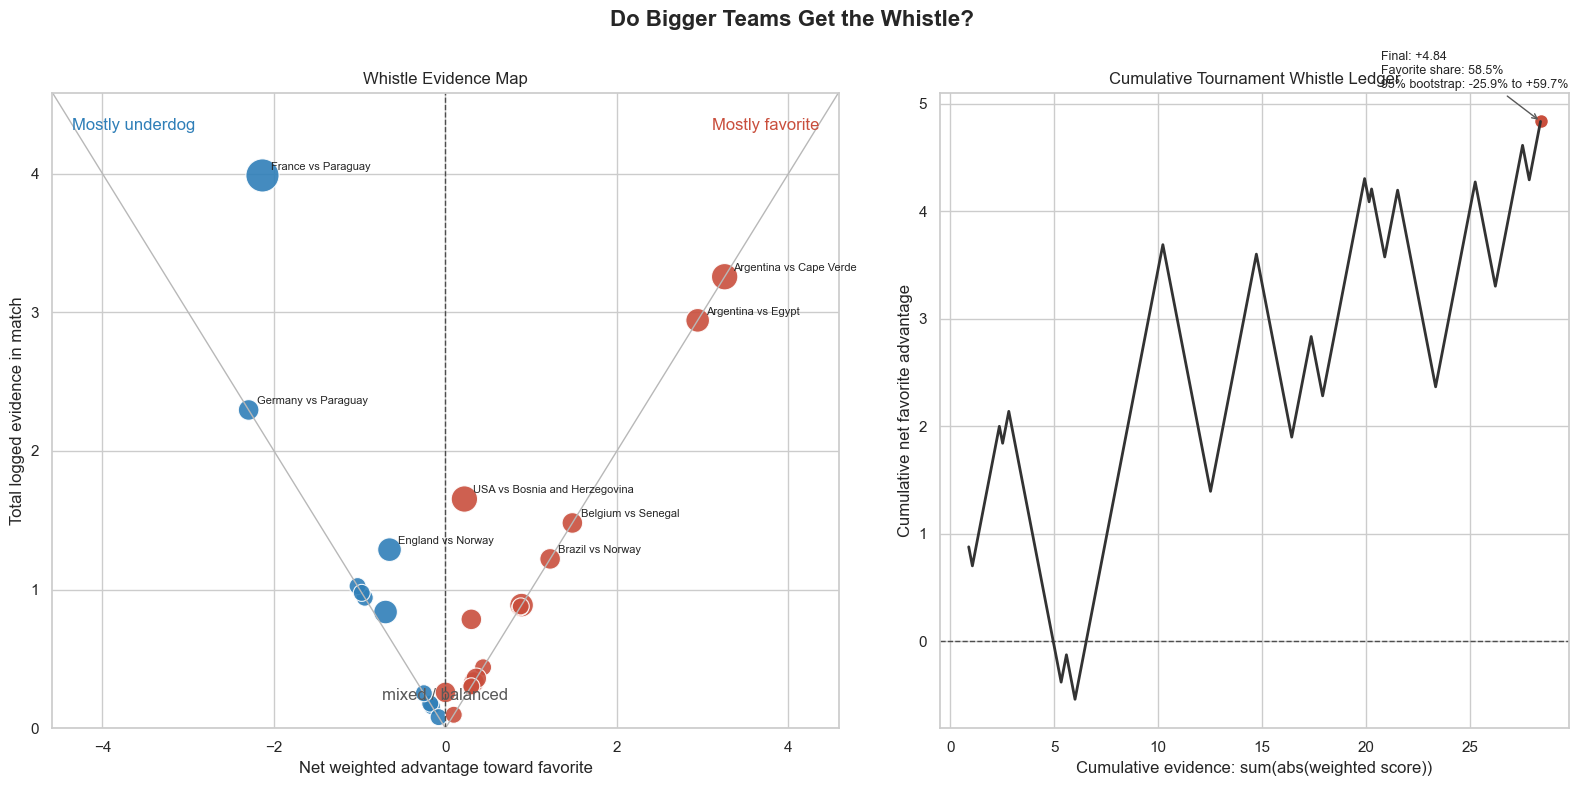

Saved chart: C:\Users\perei\OneDrive\Desktop\wc26\outputs\charts\ultimate_whistle_evidence_map.png
Saved match summary: C:\Users\perei\OneDrive\Desktop\wc26\outputs\charts\ultimate_match_whistle_summary.csv
Favorites received 58.5% of total weighted bias significance.
Underdogs received 41.5% of total weighted bias significance.
Net favorite advantage: +17.0%.
95% match-bootstrap interval: -25.9% to +59.7%.


In [26]:
from pathlib import Path
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

LEAVE_ONE_OUT_TEAM = globals().get("LEAVE_ONE_OUT_TEAM", "")

ROOT = Path.cwd().resolve()
while not (ROOT / "data" / "processed" / "cleaned.csv").exists() and ROOT != ROOT.parent:
    ROOT = ROOT.parent

OUT = ROOT / "outputs" / "charts"
OUT.mkdir(parents=True, exist_ok=True)

df = pd.read_csv(ROOT / "data" / "processed" / "cleaned.csv")

for col in ["match", "stage", "favored_team", "underdog_team", "team_benefited", "team_hurt"]:
    df[col] = df[col].astype("string").str.strip().str.replace(r"\s+", " ", regex=True).str.casefold()

df["stage"] = df["stage"].str.upper()

for col in ["score", "call_correctness", "confidence", "standard_fit", "minute"]:
    df[col] = pd.to_numeric(df[col], errors="raise")

def title_team(x):
    return (
        str(x).title()
        .replace("Usa", "USA")
        .replace("Dr Congo", "DR Congo")
        .replace(" And ", " and ")
    )

def normalize_team_value(team):
    return " ".join(str(team).strip().split()).casefold()

def leave_one_out_filter(data, team, columns=("favored_team", "underdog_team", "team_benefited", "team_hurt")):
    if team is None or str(team).strip() == "":
        return data.copy(), pd.DataFrame(columns=data.columns), "", ""

    team_key = normalize_team_value(team)
    team_columns = [col for col in columns if col in data.columns]
    involved = data[team_columns].eq(team_key).fillna(False).any(axis=1)

    if not involved.any():
        available = sorted(pd.unique(data[team_columns].stack().dropna()))
        options = ", ".join(title_team(x) for x in available)
        raise ValueError(f"No incidents found for '{team}'. Try one of: {options}")

    remaining = data.loc[~involved].copy()
    dropped = data.loc[involved].copy()
    label = title_team(team_key)
    slug = team_key.replace(" ", "_")

    if remaining.empty:
        raise ValueError(f"Leave-one-out removed every incident for {label}.")

    print(
        f"Leave-one-out: removed {len(dropped)} incidents across "
        f"{dropped['match'].nunique()} matches involving {label}."
    )
    return remaining, dropped, label, slug

df, leave_one_out_dropped, leave_one_out_label, leave_one_out_slug = leave_one_out_filter(
    df,
    LEAVE_ONE_OUT_TEAM,
)

df["weighted_score"] = (
    df["score"]
    * ((1 - df["call_correctness"]).clip(0, 1) ** 1.5)
    * df["confidence"]
    * (1 + 0.5 * df["standard_fit"].abs())
)
df["abs_weighted_score"] = df["weighted_score"].abs()

match = (
    df.groupby("match", as_index=False)
    .agg(
        stage=("stage", "first"),
        favored_team=("favored_team", "first"),
        underdog_team=("underdog_team", "first"),
        incidents=("incident_id", "count"),
        net_favorite_advantage=("weighted_score", "sum"),
        evidence=("abs_weighted_score", "sum"),
    )
)
match = match[match["evidence"] > 0].copy()

match["label"] = match["favored_team"].map(title_team) + " vs " + match["underdog_team"].map(title_team)

stage_order = {"R32": 1, "R16": 2, "QF": 3, "SF": 4, "3P": 5, "F": 6}
df["stage_order"] = df["stage"].map(stage_order).fillna(99)
df = df.sort_values(["stage_order", "minute", "incident_id"]).copy()
df["cum_evidence"] = df["abs_weighted_score"].cumsum()
df["cum_net_favorite_advantage"] = df["weighted_score"].cumsum()

total_net = df["weighted_score"].sum()
total_evidence = df["abs_weighted_score"].sum()
if match.empty or total_evidence <= 0:
    raise ValueError("No non-zero evidence remains after the leave-one-out filter.")

favorite_share = 100 * ((total_evidence + total_net) / 2) / total_evidence
underdog_share = 100 - favorite_share
net_pct = 100 * total_net / total_evidence

rng = np.random.default_rng(42)
net = match["net_favorite_advantage"].to_numpy()
evidence = match["evidence"].to_numpy()
boots = []
for _ in range(10_000):
    idx = rng.integers(0, len(match), len(match))
    boots.append(100 * net[idx].sum() / evidence[idx].sum())
ci_low, ci_high = np.percentile(boots, [2.5, 97.5])

fav_color = "#c94f3d"
dog_color = "#2f7fb8"
neutral = "#777777"

fig, (ax_map, ax_ledger) = plt.subplots(
    1, 2, figsize=(16, 8), gridspec_kw={"width_ratios": [1.25, 1]}
)

limit = match["evidence"].max() * 1.15
colors = np.where(match["net_favorite_advantage"] > 0, fav_color, np.where(match["net_favorite_advantage"] < 0, dog_color, neutral))
sizes = 80 + 70 * match["incidents"]

ax_map.plot([0, limit], [0, limit], color="0.72", linewidth=1)
ax_map.plot([0, -limit], [0, limit], color="0.72", linewidth=1)
ax_map.axvline(0, color="0.30", linestyle="--", linewidth=1)
ax_map.scatter(match["net_favorite_advantage"], match["evidence"], s=sizes, c=colors, edgecolor="white", linewidth=0.8, alpha=0.9)

label_rows = match[
    (match["evidence"] >= match["evidence"].quantile(0.72))
    | (match["net_favorite_advantage"].abs() >= match["net_favorite_advantage"].abs().quantile(0.82))
]
for _, row in label_rows.iterrows():
    ax_map.annotate(row["label"], (row["net_favorite_advantage"], row["evidence"]), xytext=(6, 4), textcoords="offset points", fontsize=8)

ax_map.set_title("Whistle Evidence Map")
ax_map.set_xlabel("Net weighted advantage toward favorite")
ax_map.set_ylabel("Total logged evidence in match")
ax_map.set_xlim(-limit, limit)
ax_map.set_ylim(0, limit)
ax_map.text(-limit * 0.95, limit * 0.96, "Mostly underdog", color=dog_color, ha="left", va="top")
ax_map.text(limit * 0.95, limit * 0.96, "Mostly favorite", color=fav_color, ha="right", va="top")
ax_map.text(0, limit * 0.04, "mixed / balanced", ha="center", va="bottom", color="0.35")

ax_ledger.axhline(0, color="0.30", linestyle="--", linewidth=1)
ax_ledger.plot(df["cum_evidence"], df["cum_net_favorite_advantage"], color="0.20", linewidth=2)
ax_ledger.scatter(df["cum_evidence"].iloc[-1], df["cum_net_favorite_advantage"].iloc[-1], color=fav_color if total_net > 0 else dog_color, edgecolor="white", s=100)

ax_ledger.set_title("Cumulative Tournament Whistle Ledger")
ax_ledger.set_xlabel("Cumulative evidence: sum(abs(weighted score))")
ax_ledger.set_ylabel("Cumulative net favorite advantage")
ax_ledger.annotate(
    f"Final: {total_net:+.2f}\nFavorite share: {favorite_share:.1f}%\n95% bootstrap: {ci_low:+.1f}% to {ci_high:+.1f}%",
    (df["cum_evidence"].iloc[-1], df["cum_net_favorite_advantage"].iloc[-1]),
    xytext=(-115, 24),
    textcoords="offset points",
    fontsize=9,
    arrowprops={"arrowstyle": "->", "color": "0.35"},
)

title_suffix = f" (without {leave_one_out_label})" if leave_one_out_label else ""
fig.suptitle(f"Do Bigger Teams Get the Whistle?{title_suffix}", fontsize=16, fontweight="bold")
fig.tight_layout()

output_suffix = f"_without_{leave_one_out_slug}" if leave_one_out_slug else ""
output_path = OUT / f"ultimate_whistle_evidence_map{output_suffix}.png"
summary_path = OUT / f"ultimate_match_whistle_summary{output_suffix}.csv"

fig.savefig(output_path, dpi=300, bbox_inches="tight")
match.sort_values("evidence", ascending=False).to_csv(summary_path, index=False)

plt.show()

print(f"Saved chart: {output_path}")
print(f"Saved match summary: {summary_path}")
print(f"Favorites received {favorite_share:.1f}% of total weighted bias significance.")
print(f"Underdogs received {underdog_share:.1f}% of total weighted bias significance.")
print(f"Net favorite advantage: {net_pct:+.1f}%.")
print(f"95% match-bootstrap interval: {ci_low:+.1f}% to {ci_high:+.1f}%.")